## **MARKETING ANALYSIS PROJECT (IN PROGRESS)**

#### Problem scenario: 
Marketing mix stands as a widely utilized concept in the execution of marketing strategies. It encompasses various facets within a comprehensive marketing plan, with a central focus on the four Ps of marketing: product, price, place, and promotion.

#### Problem objective:
As a data scientist, you must conduct exploratory data analysis and hypothesis testing to enhance your comprehension of the diverse factors influencing customer acquisition.

#### Data description:
The dataset aligns with the Four Ps of Marketing, categorizing variables to analyze consumer behavior. Product-related variables track spending across categories, while Price factors like income and deal-based purchases indicate affordability. Place covers shopping channels and web visits, reflecting purchase preferences. Promotion measures campaign engagement, complaints, and recency. Additionally, demographics support segmentation for personalized marketing. This structured approach helps businesses optimize products, pricing, distribution, and promotions for better customer engagement and market performance.


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import scipy 
from matplotlib.ticker import FuncFormatter
from sklearn.preprocessing import MinMaxScaler

#read in the data from the csv file
df = pd.read_csv("marketing_data.csv")




In [77]:
#MEMORY OPTIMIZATION

# To preserve memory, downcast the integer columns to the smallest possible integer type to save memory
integer_columns = df.select_dtypes(include=["int"]).columns
df[integer_columns] = df[integer_columns].apply(pd.to_numeric, downcast="integer")

#To preserve memory, change the data column to datetime type
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], errors="coerce", format="%m/%d/%y")

#change object columns to category or string type
object_columns = df.select_dtypes(include=["object"]).columns
df[object_columns] = df[object_columns].astype("category")  


In [78]:
#DATA CLEANING

#strip leading and trailing spaces from column names
df.columns = df.columns.str.strip()

#replace $ and comma sign from the Income column with "" and change the column to float type
df["Income"] = (
    df["Income"]
    .astype("string")
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float)
)
#How many duplicate rows are there disregarding the ID column
print("\nNumber of duplicate rows (ignoring ID):", df.drop(columns=["ID"]).duplicated().sum())
#keep one of the duplicates and drop the rest
df = df.drop_duplicates(subset=df.columns.difference(["ID"]), keep="first")
print("\nNumber of duplicate rows after dropping (ignoring ID):", df.drop(columns=["ID"]).duplicated().sum())  

#Update Marital_Status to Married where it says Together
df["Marital_Status"] = df["Marital_Status"].replace("Together", "Married")
#update MArital_Status to Single where it says Widow, Divorced or Alone
df["Marital_Status"] = df["Marital_Status"].replace(["Widow", "Divorced", "Alone", "YOLO", "Absurd"], "Single")

#Check Dt_Customer and income separately for missing values
print("\nThere are " + str(df["Dt_Customer"].isna().sum()) + " missing values in the Dt_Customer column")
print("There are " + str(df["Income"].isna().sum()) + " missing values in the Income column")

#print out categories of education and marital status
print("\n", df["Education"].value_counts())
print(df["Marital_Status"].value_counts())

#what is the mean, median and mode of the income grouped by education and marital status. format so that mean, median and mode are displayed with two decimal places and are on the same line for each education/marital status combination. store these results in a dataframe
grouped_by_education_marital = df.groupby(["Education", "Marital_Status"])["Income"]
summary = grouped_by_education_marital.agg([("Mean", lambda x: f"{x.mean():.2f}"),
                                             ("Median", lambda x: f"{x.median():.2f}"),
                                             ("Mode", lambda x: f"{x.mode().iloc[0]:.2f}" if not x.mode().empty else "NaN")])
print(summary)

#For the rows where income is missing, fill in the income with the mean income for the corresponding education and marital status combination
df["Income"] = df.apply(lambda row: summary.loc[(row["Education"], row["Marital_Status"]), "Mean"] if pd.isna(row["Income"]) else row["Income"], axis=1)




Number of duplicate rows (ignoring ID): 0

Number of duplicate rows after dropping (ignoring ID): 0

There are 0 missing values in the Dt_Customer column
There are 0 missing values in the Income column

 Education
Graduation    1101
PhD            475
Master         366
2n Cycle       197
Basic           54
Name: count, dtype: int64
Marital_Status
Married    1415
Single      778
Name: count, dtype: int64
                               Mean    Median      Mode
Education  Marital_Status                              
2n Cycle   Married         45424.36  45659.18   7500.00
           Single          51957.98  49118.00  31163.00
Basic      Married         21663.85  23179.00  20425.00
           Single          17998.35  16383.00   7500.00
Graduation Married         52981.86  52688.00  52981.86
           Single          52729.66  52729.66  52729.66
Master     Married         52853.76  51188.50  52853.76
           Single          52854.54  51257.00  46098.00
PhD        Married         5721

/var/folders/6z/wpyb8d7117jfzlw85lcp_z940000gn/T/ipykernel_36336/1966939704.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_by_education_marital = df.groupby(["Education", "Marital_Status"])["Income"]


In [79]:
# Create a total spending column
df["Total_Spending"] = df[
    [
        "MntWines",
        "MntFruits",
        "MntMeatProducts",
        "MntFishProducts",
        "MntSweetProducts",
        "MntGoldProds",
    ]
].sum(axis=1)

# Create a total children column
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

# Create an age column
df["Age"] = 2026 - df["Year_Birth"]

# Create a total purchases column
df["Total_Purchases"] = df[
    [
        "NumDealsPurchases",
        "NumWebPurchases",
        "NumCatalogPurchases",
        "NumStorePurchases",
    ]
].sum(axis=1)

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Total_Spending,Total_Children,Age,Age_Bucket,Total_Purchases
0,1826,1970,Graduation,Single,84835.0,0,0,2014-06-16,0,189,...,0,0,1,0,SP,1190,0,56,50,15
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,0,1,1,0,CA,577,0,65,60,18
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,0,0,0,0,US,251,1,68,60,11
3,1386,1967,Graduation,Married,32474.0,1,1,2014-05-11,0,10,...,0,0,0,0,AUS,11,2,59,50,4
4,5371,1989,Graduation,Single,21474.0,1,0,2014-04-08,0,6,...,0,0,1,0,SP,91,1,37,30,8


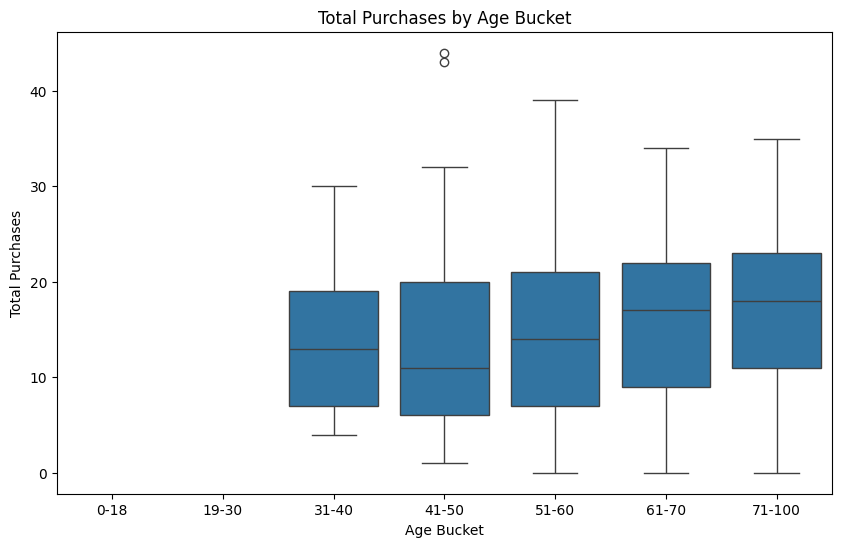

Age_Bucket
0-18          0
19-30         0
31-40      1964
41-50      5847
51-60     10157
61-70      7585
71-100     7025
Name: Total_Purchases, dtype: int64


/var/folders/6z/wpyb8d7117jfzlw85lcp_z940000gn/T/ipykernel_36336/2475152360.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("Age_Bucket")["Total_Purchases"].sum())


In [81]:
#based on age bucket generate box plots 
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x="Age_Bucket", y="Total_Purchases", data=df)
plt.title("Total Purchases by Age Bucket")
plt.xlabel("Age Bucket")
plt.ylabel("Total Purchases")
plt.show()  
bins = [0, 18, 30, 40, 50, 60, 70, 100]
labels = ["0-18", "19-30", "31-40", "41-50", "51-60", "61-70", "71-100"]
df["Age_Bucket"] = pd.cut(df["Age"], bins=bins, labels=labels, right=False)

print(df.groupby("Age_Bucket")["Total_Purchases"].sum())